<a href="https://colab.research.google.com/github/KKseniyaP/LearningProjects/blob/main/ANN_LR4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Сверточные нейронные сети



#Создание простой модели сверточной нейронной сети

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D

model = Sequential()

# Первый сверточный слой
model.add(Conv2D(8,                        #количество ядер (фильтров) свертки
                 (3, 3),                   #размер ядра свертки,
                 padding='same',           #тип заполнения краев
                 activation='relu',        #указание функции активации
                 input_shape=(28, 56, 3))) #форма входящего массива, размер изображения 28*56, 3-шаг смещения фильтра

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 56, 8)      │           224 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 224 (896.00 B)

 Trainable params: 224 (896.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Второй сверточный слой
model.add(Conv2D(5, (3, 2), strides = (2,3),
                 padding='valid', #если padding='valid',
                 #то по правилам pad = 0, output_h = (input_h + 2 * pad - size) // stride + 1 ,
                 #output_w = (input_w + 2 * pad - size) // stride + 1
                 activation='relu'))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 56, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 19, 5)      │           245 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 469 (1.83 KB)

 Trainable params: 469 (1.83 KB)

 Non-trainable params: 0 (0.00 B)

Применим слой MaxPooling2D:
MaxPooling2D изменит форму данных следующим образом (учитывая, что stride=pool_size):
*   output_h = (input - pool_size) // strides + 1 = (13 - 3) // 3 + 1 = 4
*   output_w = (input - pool_size) // strides + 1 = (19 - 3) // 3 + 1 = 6

In [ ]:
from tensorflow.keras.layers import MaxPooling2D
# Слой подвыборки
model.add(MaxPooling2D(pool_size=(3, 3)))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 56, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 19, 5)      │           245 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 6, 5)        │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 469 (1.83 KB)

 Trainable params: 469 (1.83 KB)

 Non-trainable params: 0 (0.00 B)

Далее слой Flatten преобразует входящий тензор в одномерный вектор.

In [ ]:
from tensorflow.keras.layers import Flatten

# Слой преобразования многомерных данных в одномерные
model.add(Flatten())
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 56, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 19, 5)      │           245 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 6, 5)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 120)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 469 (1.83 KB)

 Trainable params: 469 (1.83 KB)

 Non-trainable params: 0 (0.00 B)

#Распознавание изображений из набора данных MNIST

In [ ]:
from tensorflow.keras.datasets import mnist #
from tensorflow.keras.datasets import cifar10 #
from tensorflow.keras.datasets import cifar100 #

from tensorflow.keras.models import Sequential
#Базовые слои для свёрточных сетей
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam, Adadelta
from tensorflow.keras import utils
from tensorflow.keras.preprocessing import image
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random
import math
import os
from google.colab import drive

%matplotlib inline

Подготовка данных

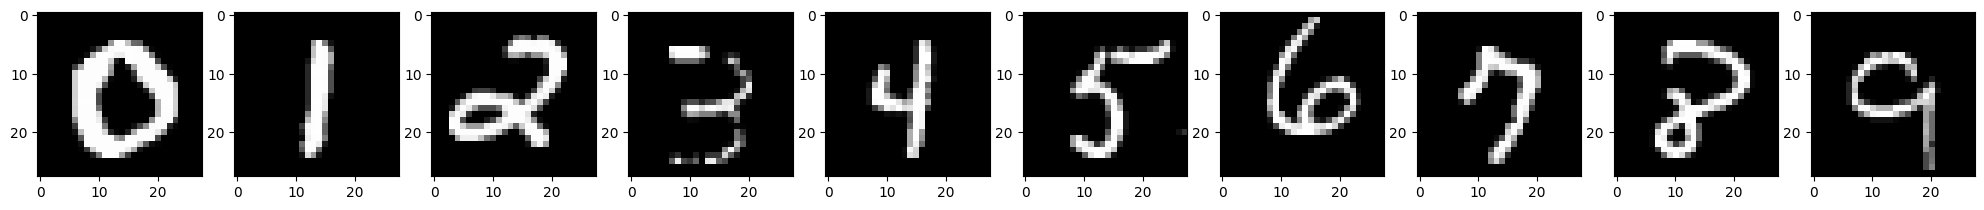

In [ ]:
#Загружаем MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train.shape
(60000, 28, 28)

#Выводим  картинки по каждому классу
fig, axs = plt.subplots(1, 10, figsize=(25, 3))
for i in range(10):
  label_indexes = np.where(y_train==i)[0]
  index = random.choice(label_indexes)
  img = x_train[index] #
  axs[i].imshow(Image.fromarray(img), cmap='gray') #
plt.show() #
y_train = utils.to_categorical(y_train, 10)
y_test = utils.to_categorical(y_test, 10)

In [ ]:
#Меняем формат данных MNIST
#Добавляем одну размерность для подачи на вход сверточного слоя
# чёрно-белые данные
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)
# Посмотрим форматы выборок перед обучением
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)
(60000, 10)
(10000, 10)


#Нейронная сеть

In [ ]:
#задаём batch_size
batch_size = 128
#Создаем последовательную модель
model = Sequential()
#Слой пакетной нормализации
model.add(BatchNormalization(input_shape=(28, 28, 1)))
#Первый сверточный слой
model.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
#Второй сверточный слой
model.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
#Первый слой подвыборки
model.add(MaxPooling2D(pool_size=(2, 2)))
#Слой регуляризации Dropout
model.add(Dropout(0.25))
model.add(Flatten())
#Полносвязный слой для классификации
model.add(Dense(256, activation='relu'))
#Слой регуляризации Dropout
model.add(Dropout(0.25))
#Выходной полносвязный слой
model.add(Dense(10, activation='softmax'))

#Компилируем сеть
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_1           │ (None, 28, 28, 1)      │             4 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,618,030 (6.17 MB)

 Trainable params: 1,618,028 (6.17 MB)

 Non-trainable params: 2 (8.00 B)

In [ ]:
#Обучаем сеть на данных mnist
history = model.fit(x_train,
                    y_train,
                    batch_size=batch_size,
                    epochs=15,
                    validation_data=(x_test, y_test),
                    verbose=1)
model.summary()

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 93s 196ms/step - accuracy: 0.9498 - loss: 0.1651 - val_accuracy: 0.9835 - val_loss: 0.0504
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 144s 200ms/step - accuracy: 0.9844 - loss: 0.0516 - val_accuracy: 0.9890 - val_loss: 0.0334
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 140s 196ms/step - accuracy: 0.9883 - loss: 0.0363 - val_accuracy: 0.9882 - val_loss: 0.0345
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 91s 194ms/step - accuracy: 0.9913 - loss: 0.0273 - val_accuracy: 0.9905 - val_loss: 0.0309
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 144s 198ms/step - accuracy: 0.9925 - loss: 0.0227 - val_accuracy: 0.9896 - val_loss: 0.0323
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 195ms/step - accuracy: 0.9941 - loss: 0.0181 - val_accuracy: 0.9906 - val_loss: 0.0296
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 197ms/step - accuracy: 0.9942 - loss: 0.0165 - val_accuracy: 0.9906 - val_loss: 0.0286
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 93s 199ms/step - accuracy: 0.9954 - lo

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_1           │ (None, 28, 28, 1)      │             4 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,854,088 (18.52 MB)

 Trainable params: 1,618,028 (6.17 MB)

 Non-trainable params: 2 (8.00 B)

 Optimizer params: 3,236,058 (12.34 MB)

#Практическое задание 1

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D,
    MaxPooling2D,
    AveragePooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization)

Сеть 1 (Базовая с ReLU и MaxPooling):

In [ ]:
model1 = Sequential([
    Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
model1.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 804,554 (3.07 MB)

 Trainable params: 804,554 (3.07 MB)

 Non-trainable params: 0 (0.00 B)

Сеть 2 (С padding='valid', AveragePooling и другой активацией):


In [ ]:
model2 = Sequential([
    Conv2D(16, (3, 3), padding='valid', activation='tanh', input_shape=(28, 28, 1)),
    AveragePooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(64, activation='tanh'),
    Dense(10, activation='softmax')
])
model2.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 13, 13, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 2704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │       173,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 173,930 (679.41 KB)

 Trainable params: 173,930 (679.41 KB)

 Non-trainable params: 0 (0.00 B)

Сеть 3 (С strides>1, Dropout и ещё одним сверточным слоем):

In [ ]:
model3 = Sequential([
    BatchNormalization(input_shape=(28, 28, 1)),
    Conv2D(32, (3, 3), padding='same', strides=(2, 2), activation='elu', input_shape=(28, 28, 1)),
    # Добавили ещё один сверточный слой для глубины
    Conv2D(64, (3, 3), padding='valid', activation='elu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])
model3.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 28, 28, 1)      │             4 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 611,470 (2.33 MB)

 Trainable params: 611,468 (2.33 MB)

 Non-trainable params: 2 (8.00 B)

# Задание 2

In [ ]:
model4 = Sequential([
    Input(shape=(28, 28, 1)),                                       # форма входа: 28×28, 1 канал
    BatchNormalization(),                                           # нормализация входа
    Conv2D(32, (3, 3), padding='same', strides=(2, 2), activation='elu'),  # 1-й свёрточный слой
    Conv2D(64, (3, 3), padding='valid', activation='elu'),          # 2-й свёрточный слой
    MaxPooling2D(pool_size=(2, 2)),                                 # подвыборка
    Flatten(),                                                      # вытягиваем в вектор
    Dense(128, activation='relu'),                                  # полносвязный слой
    Dropout(0.5),                                                   # регуляризация
    Dense(10, activation='softmax')                                 # выход: 10 классов
])

model4.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_5           │ (None, 28, 28, 1)      │             4 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 14, 14, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,150 (1.20 MB)

 Trainable params: 315,148 (1.20 MB)

 Non-trainable params: 2 (8.00 B)

In [ ]:
# загрузка mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Нормализация + форма (N, 28, 28, 1)
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test  = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# One-hot кодирование меток
y_train = utils.to_categorical(y_train, 10)
y_test  = utils.to_categorical(y_test, 10)

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_test :", x_test.shape)
print("y_test :", y_test.shape)

x_train: (60000, 28, 28, 1)
y_train: (60000, 10)
x_test : (10000, 28, 28, 1)
y_test : (10000, 10)


In [ ]:
# компиляция
model4.compile(loss='categorical_crossentropy',
               optimizer='adam',
               metrics=['accuracy'])

# обучение
history = model4.fit(x_train, y_train,
                     batch_size=128,
                     epochs=10,
                     validation_data=(x_test, y_test),
                     verbose=1)

# оценка на тесте
score = model4.evaluate(x_test, y_test, verbose=0)
print(f"\nTest accuracy: {score[1]:.4f}")
print(f"Test loss:     {score[0]:.4f}")

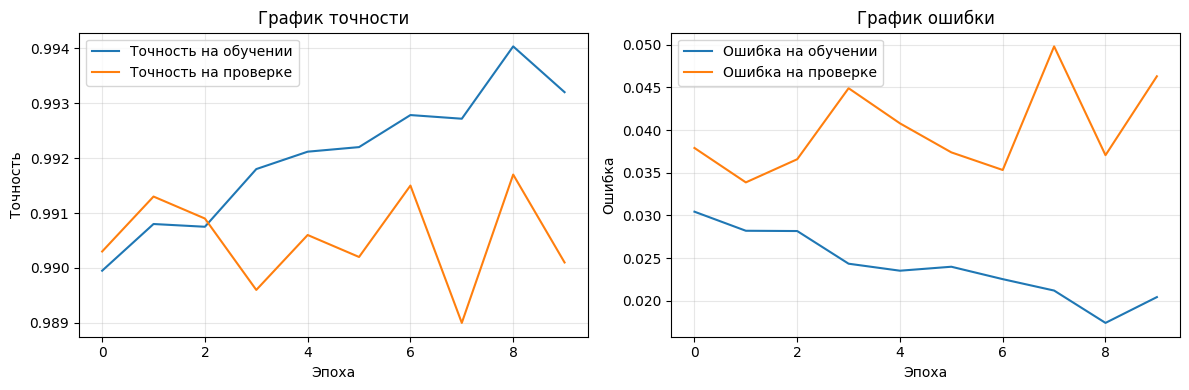

In [ ]:
# графики обучения
plt.figure(figsize=(12, 4))

# График точности
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Точность на обучении')
plt.plot(history.history['val_accuracy'], label='Точность на проверке')
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.title('График точности')
plt.legend()
plt.grid(True, alpha=0.3)

# График ошибки
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Ошибка на обучении')
plt.plot(history.history['val_loss'], label='Ошибка на проверке')
plt.xlabel('Эпоха')
plt.ylabel('Ошибка')
plt.title('График ошибки')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# подготовка фото
def prepare_for_cnn(path):
    """
    Готовит изображение к подаче в Conv2D-сеть, обученную на MNIST.
    Возвращает массив формы (1, 28, 28, 1).
    """
    # 1. Открыть и перевести в оттенки серого
    img = Image.open(path).convert('L')
    arr = np.array(img)

    # 2. Автоопределение фона: если фон светлый — инвертируем
    #    (в MNIST цифра белая на чёрном фоне)
    if arr.mean() > 127:
        arr = 255 - arr
    img = Image.fromarray(arr)

    # 3. Обрезка по границам цифры (bbox ярких пикселей)
    bbox = img.point(lambda p: 255 if p > 30 else 0).getbbox()
    if bbox:
        img = img.crop(bbox)

    # 4. Вписать в 20×20, затем в 28×28 с паддингом по центру
    #    (как в MNIST: цифра занимает ~20×20 в центре 28×28)
    img.thumbnail((20, 20), Image.LANCZOS)
    canvas = Image.new('L', (28, 28), 0)
    canvas.paste(img, ((28 - img.width) // 2, (28 - img.height) // 2))

    # 5. Нормализация и форма для Conv2D
    arr = np.array(canvas).astype('float32') / 255.0
    return arr.reshape(1, 28, 28, 1)

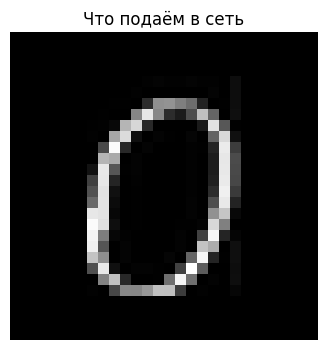

In [ ]:
# Проверим на одной картинке
test_path = '/content/0.jpeg'
if os.path.exists(test_path):
    x_test_img = prepare_for_cnn(test_path)
    plt.figure(figsize=(4, 4))
    plt.imshow(x_test_img.reshape(28, 28), cmap='gray')
    plt.title('Что подаём в сеть')
    plt.axis('off')
    plt.show()

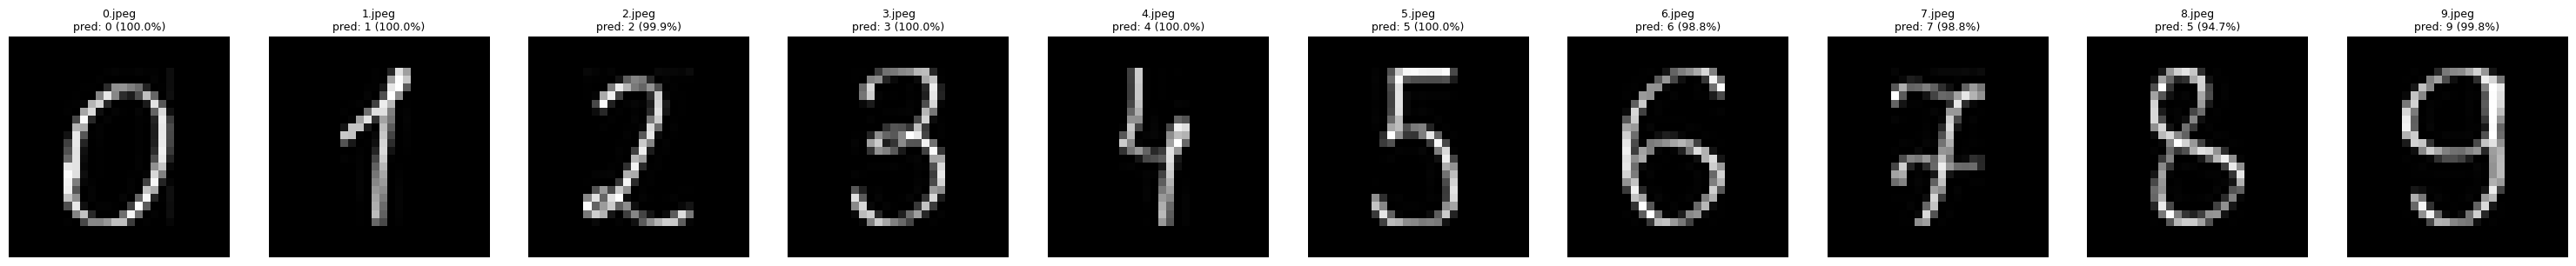

In [ ]:

folder = '/content'
exts = ('.png', '.jpg', '.jpeg', '.bmp')

files = [f for f in sorted(os.listdir(folder)) if f.lower().endswith(exts)]

if not files:
    print(f"В папке {folder} нет картинок!")
else:
    results = []
    for fname in files:
        path = os.path.join(folder, fname)
        x = prepare_for_cnn(path)
        pred = model4.predict(x, verbose=0)[0]
        cls = int(np.argmax(pred))
        conf = float(pred.max())
        results.append((fname, x, cls, conf))
        #print(f"{fname:25s} → цифра {cls}  (уверенность {conf:.1%})")

    # ---- Визуализация ----
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    if n == 1:
        axes = [axes]

    for ax, (fname, x, cls, conf) in zip(axes, results):
        ax.imshow(x.reshape(28, 28), cmap='gray')
        ax.set_title(f"{fname}\npred: {cls} ({conf:.1%})", fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    plt.show()